[49.38204456 57.47546169 49.60886667 61.00406551 53.40972635 33.74781612
 51.65934581 50.09966669 43.77803076 62.90358262]
Outlier Indices: [391 477 708 792]
Outlier Values: [89.46866968 18.54116772 87.1524168  12.7310972 ]


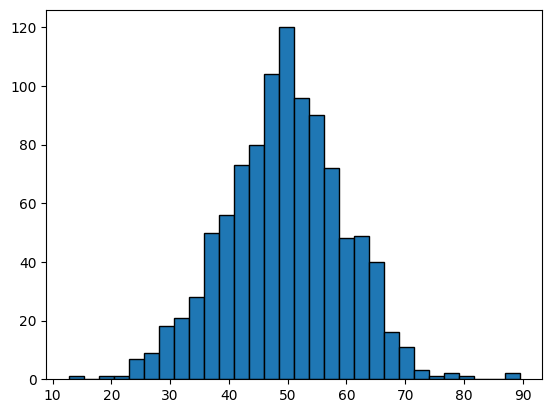

In [11]:
import numpy as np
import matplotlib.pyplot as plt
def detect_outliers_zscore(data, threshold=3):
   mean = np.mean(data)
   std = np.std(data)
   z_scores = (data - mean) / std
   outlier_indices = np.where(np.abs(z_scores) > threshold)
   outlier_values = data[outlier_indices]
   return outlier_indices[0], outlier_values
# Example dataset
data = np.random.normal(loc=50, scale=10, size=1000)

print(data[:10])  # show first 10 values
plt.hist(data,bins=30,edgecolor="black")
indices, values = detect_outliers_zscore(data)
print("Outlier Indices:", indices)
print("Outlier Values:", values)

In [12]:
import numpy as np

def detect_outliers_iqr(data):
    Q1 = np.percentile(data, 25)
    Q3 = np.percentile(data, 75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outlier_indices = np.where((data < lower_bound) | (data > upper_bound))
    outlier_values = data[outlier_indices]
    
    return outlier_indices[0], outlier_values

# Example dataset
data = np.array([5, 2, 4.5, 4, 3, 2, 6, 20, 9, 2.5])
indices, values = detect_outliers_iqr(data)

print("Outlier Indices:", indices)
print("Outlier Values:", values)

Outlier Indices: [7]
Outlier Values: [20.]


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
df=pd.read_csv(r"N:\Data\placement.csv")
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


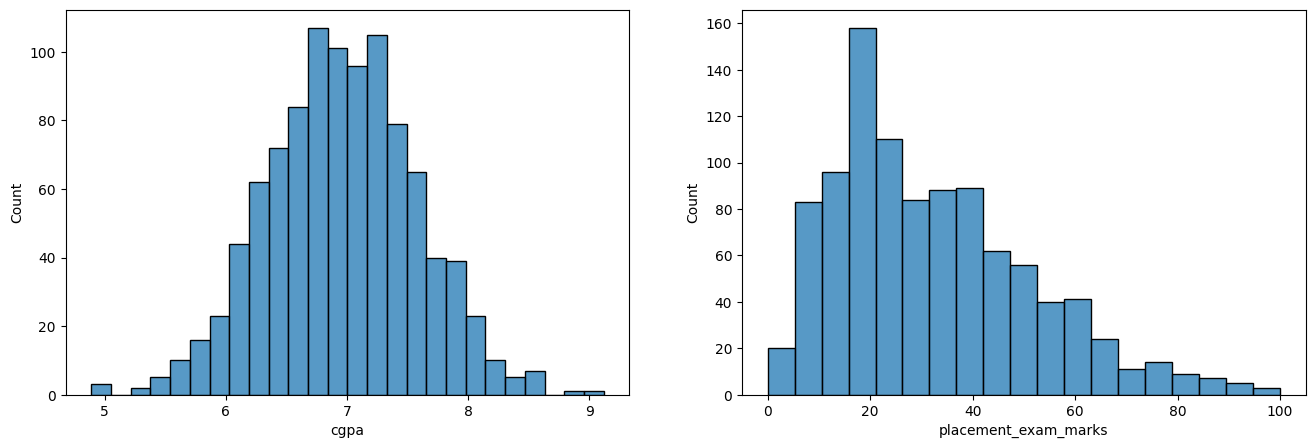

In [17]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.histplot(df['cgpa'])

plt.subplot(1,2,2)
sns.histplot(df['placement_exam_marks'])

plt.show()

In [18]:
df['placement_exam_marks'].describe()

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

<Axes: ylabel='placement_exam_marks'>

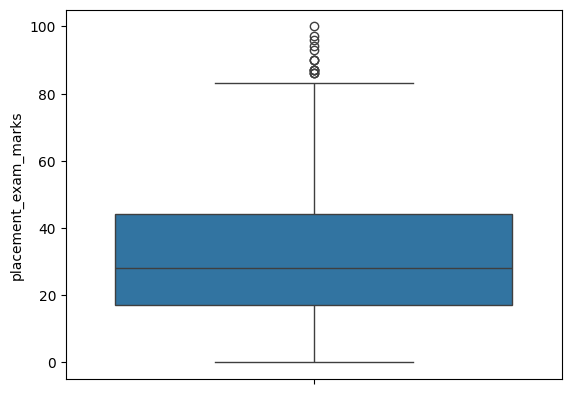

In [19]:
sns.boxplot(df['placement_exam_marks'])

In [20]:
percentile25=np.percentile(df['placement_exam_marks'],25)
percentile75=np.percentile(df['placement_exam_marks'],75)

In [21]:
percentile75

44.0

In [22]:
iqr=percentile75-percentile25

In [23]:
iqr

27.0

In [24]:
upper_limit=percentile75+iqr*1.5
lower_limit=percentile25-iqr*1.5

In [25]:

print("Upper limit",upper_limit)
print("Lower limit",lower_limit)

Upper limit 84.5
Lower limit -23.5


In [26]:
df[df['placement_exam_marks'] > upper_limit]

,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0
283,7.09,87.0,0
290,8.38,87.0,0
311,6.97,87.0,1
324,6.64,90.0,0
630,6.56,96.0,1


In [27]:

df[df['placement_exam_marks'] < lower_limit]

,cgpa,placement_exam_marks,placed


Trimming

In [28]:
new_df = df[df['placement_exam_marks'] < upper_limit]

In [29]:
new_df.shape

(985, 3)

<Axes: ylabel='placement_exam_marks'>

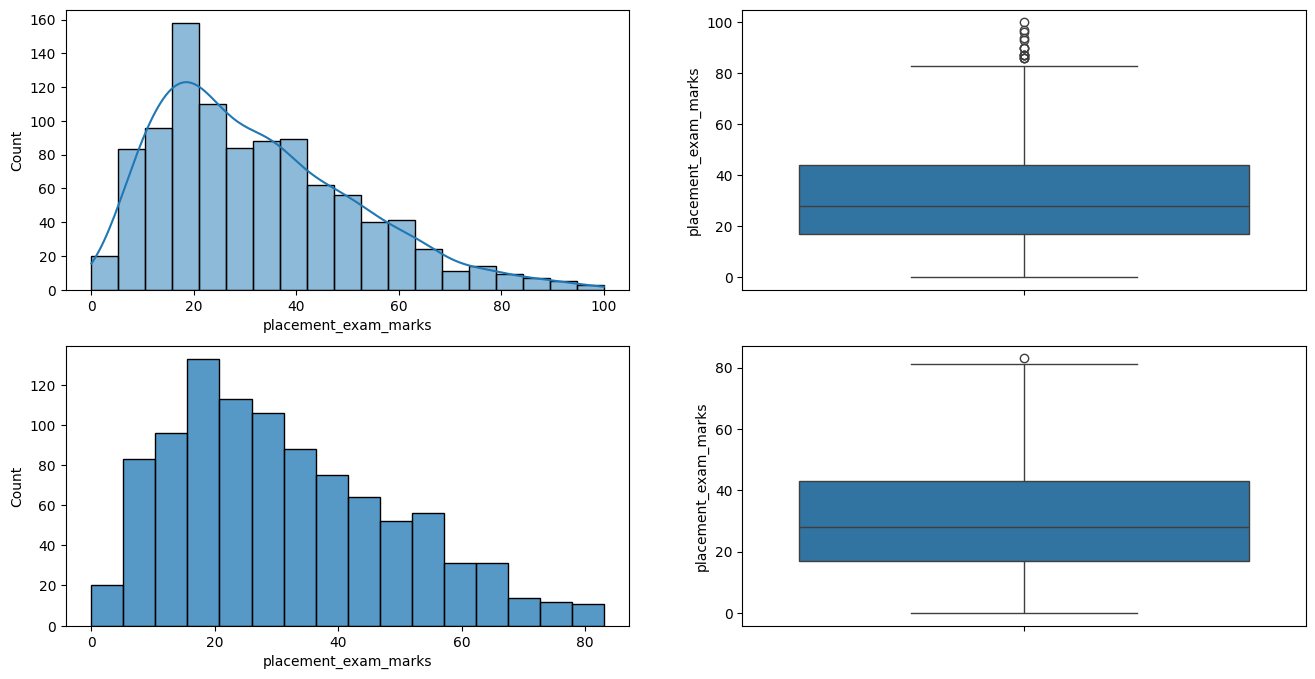

In [31]:
# Comparing

plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.histplot(df['placement_exam_marks'],kde=True)

plt.subplot(2,2,2)
sns.boxplot(df['placement_exam_marks'])

plt.subplot(2,2,3)
sns.histplot(new_df['placement_exam_marks'])

plt.subplot(2,2,4)
sns.boxplot(new_df['placement_exam_marks'])

Cappping

In [32]:
new_df_cap=df.copy()

In [34]:
new_df_cap['placement_exam_marks'] = np.where(
    new_df_cap['placement_exam_marks'] > upper_limit,
    upper_limit,
    np.where(
        new_df_cap['placement_exam_marks'] < lower_limit,
        lower_limit,
        new_df_cap['placement_exam_marks']
    )
)

In [35]:
new_df_cap.shape

(1000, 3)

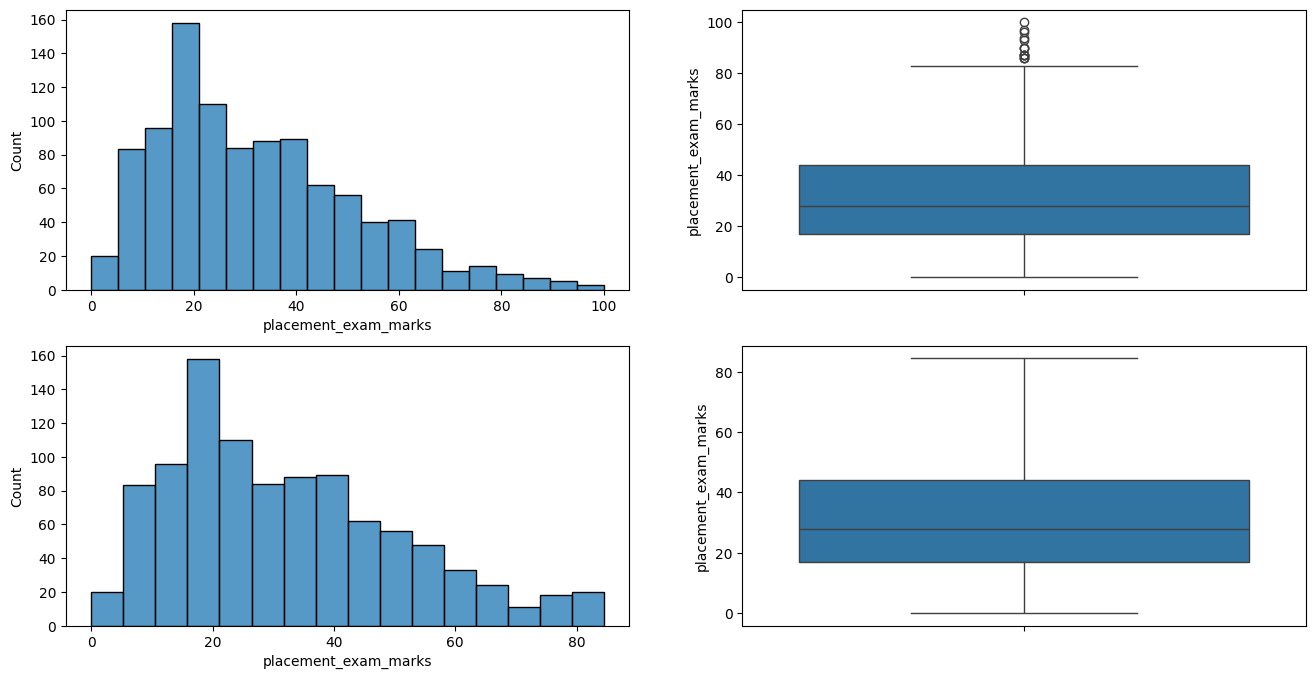

In [36]:
# Comparing

plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.histplot(df['placement_exam_marks'])

plt.subplot(2,2,2)
sns.boxplot(df['placement_exam_marks'])

plt.subplot(2,2,3)
sns.histplot(new_df_cap['placement_exam_marks'])

plt.subplot(2,2,4)
sns.boxplot(new_df_cap['placement_exam_marks'])

plt.show()